In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Reading the Evaluation data by Pathologist

In [188]:
eval_data = pd.read_csv('data/pathopen_eval_data.csv')
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,Evaluation OE_Correct_Answer_1\n(Benchmark 1),Unnamed: 6,OE_Wrong_Answer_1,Evaluation OE_Wrong_Answer_1\n(Benchmark 2),Unnamed: 9,...,Unnamed: 26,MCQ_OE_Wrong_Answer_3,Evaluation MCQ_OE_Wrong_Answer_3\n(Benchmark 2),Unnamed: 29,MCQ_OE_Wrong_Answer_4,Evaluation MCQ_OE_Wrong_Answer_4\n(Benchmark 2),Unnamed: 32,CE_Question,CE_Correct_Answer,Evaluation CE_Correct_Answer\n(Benchmark 3)
0,NaN,NaN,NaN,NaN,NaN,Knowledge Interpretation/Deduction,Visual Grounding,NaN,Error Proximity/Deductive Plausibility,Visual Grounding Error,...,Visual Grounding Error,NaN,Error Proximity/Deductive Plausibility,Visual Grounding Error,NaN,Error Proximity/Deductive Plausibility,Visual Grounding Error,NaN,NaN,Visual Grounding/Reasoning
1,153.0,img_pathopen_153_03,https://drive.google.com/open?id=174myggtY1Fj5...,How would one describe the abnormal infiltrate...,"The abnormal cells appear to show round, large...",2,2,The abnormal cells appear to show spindled mor...,1,1,...,2,The histology and immunohistochemistry suggest...,1,1,The histology and immunohistochemistry suggest...,1,1,Could this image that depicts a malignant sarc...,Yes,2
2,67.0,img_pathopen_67_01,https://drive.google.com/open?id=1iNpg3DgTGpNZ...,Considering this is an ovarian mass in a 16 ye...,This ovarian tumor has a mixture of somatic ti...,2,2,This ovarian tumor has a mixture of benign som...,2,1,...,1,PNET arising in an immature teratoma,2,2,Intermediate-to-poorly differentiated Sertoli-...,2,2,Is this tumor graded based on the amount of gl...,No,2
3,10.0,img_pathopen_10_01,https://drive.google.com/open?id=14rsOnN9AySFK...,The image shows a mixture of epithelial and me...,These are features typical of a branchial arch...,2,2,NaN,NaN,NaN,...,0,Dystrophic calcification,0,0,Necrosis,-1,-1,Does the image show features of superimposed i...,No,2
4,137.0,img_pathopen_137_03,https://drive.google.com/open?id=1tWQ8FH1UEg1U...,What is the abnormality observed in this image...,The image depicts a molar pregnancy with unifo...,2,2,The image depicts an early pregnancy with dila...,1,1,...,1,The multinucleated cells in question are synov...,0,1,The multinucleated cells in question are megak...,1,0,Does the image from this placenta suggest an u...,No,2


Renaming some columns

In [189]:
eval_data = eval_data.rename(columns={'Evaluation OE_Correct_Answer_1\n(Benchmark 1)': 'OE_Correct_Answer_1_Know_Inter',
                                        'Unnamed: 6': 'OE_Correct_Answer_1_Vis_Ground',
                                        'Evaluation OE_Wrong_Answer_1\n(Benchmark 2)': 'OE_Wrong_Answer_1_Err_Prox',
                                        'Unnamed: 9': 'OE_Wrong_Answer_1_Vis_Ground',
                                        'Evaluation OE_Correct_Answer_2\n(Benchmark 1)': 'OE_Correct_Answer_2_Know_Inter',
                                        'Unnamed: 13': 'OE_Correct_Answer_2_Vis_Ground',
                                        'Evaluation OE_Wrong_Answer_2\n(Benchmark 2)': 'OE_Wrong_Answer_2_Err_Prox',
                                        'Unnamed: 16': 'OE_Wrong_Answer_2_Vis_Ground',
                                        'Evaluation MCQ_OE_Correct_Answer\n(Benchmark 1)': 'MCQ_OE_Correct_Answer_Know_Inter',
                                        'Unnamed: 20': 'MCQ_OE_Correct_Answer_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_1\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_1_Err_Prox',
                                        'Unnamed: 23': 'MCQ_OE_Wrong_Answer_1_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_2\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_2_Err_Prox',
                                        'Unnamed: 26': 'MCQ_OE_Wrong_Answer_2_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_3\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_3_Err_Prox',
                                        'Unnamed: 29': 'MCQ_OE_Wrong_Answer_3_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_4\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_4_Err_Prox',
                                        'Unnamed: 32': 'MCQ_OE_Wrong_Answer_4_Vis_Ground',
                                        'Evaluation CE_Correct_Answer\n(Benchmark 3)': 'CE_Correct_Answer_Vis_Ground',
                                        })

eval_data = eval_data.drop(index=0) #dropping the first row which contains the benchmark names
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,OE_Correct_Answer_1_Know_Inter,OE_Correct_Answer_1_Vis_Ground,OE_Wrong_Answer_1,OE_Wrong_Answer_1_Err_Prox,OE_Wrong_Answer_1_Vis_Ground,...,MCQ_OE_Wrong_Answer_2_Vis_Ground,MCQ_OE_Wrong_Answer_3,MCQ_OE_Wrong_Answer_3_Err_Prox,MCQ_OE_Wrong_Answer_3_Vis_Ground,MCQ_OE_Wrong_Answer_4,MCQ_OE_Wrong_Answer_4_Err_Prox,MCQ_OE_Wrong_Answer_4_Vis_Ground,CE_Question,CE_Correct_Answer,CE_Correct_Answer_Vis_Ground
1,153.0,img_pathopen_153_03,https://drive.google.com/open?id=174myggtY1Fj5...,How would one describe the abnormal infiltrate...,"The abnormal cells appear to show round, large...",2,2,The abnormal cells appear to show spindled mor...,1,1,...,2,The histology and immunohistochemistry suggest...,1,1,The histology and immunohistochemistry suggest...,1,1,Could this image that depicts a malignant sarc...,Yes,2
2,67.0,img_pathopen_67_01,https://drive.google.com/open?id=1iNpg3DgTGpNZ...,Considering this is an ovarian mass in a 16 ye...,This ovarian tumor has a mixture of somatic ti...,2,2,This ovarian tumor has a mixture of benign som...,2,1,...,1,PNET arising in an immature teratoma,2,2,Intermediate-to-poorly differentiated Sertoli-...,2,2,Is this tumor graded based on the amount of gl...,No,2
3,10.0,img_pathopen_10_01,https://drive.google.com/open?id=14rsOnN9AySFK...,The image shows a mixture of epithelial and me...,These are features typical of a branchial arch...,2,2,NaN,NaN,NaN,...,0,Dystrophic calcification,0,0,Necrosis,-1,-1,Does the image show features of superimposed i...,No,2
4,137.0,img_pathopen_137_03,https://drive.google.com/open?id=1tWQ8FH1UEg1U...,What is the abnormality observed in this image...,The image depicts a molar pregnancy with unifo...,2,2,The image depicts an early pregnancy with dila...,1,1,...,1,The multinucleated cells in question are synov...,0,1,The multinucleated cells in question are megak...,1,0,Does the image from this placenta suggest an u...,No,2
5,16.0,img_pathopen_16_01,https://drive.google.com/open?id=1wyEZUuc-UTe9...,Describe the histological findings are present...,There is a dense neutrophilic infiltrate in th...,1,1,NaN,NaN,NaN,...,2,Lymphocytes,2,2,Plasma cells,2,2,Is eosinophilic infiltration a hallmark featur...,No,2


Converting all the evaluation columns from Str to Int

In [190]:
eval_data = eval_data.astype({'OE_Correct_Answer_1_Know_Inter': 'float',
                                'OE_Correct_Answer_1_Vis_Ground': 'float',
                                'OE_Wrong_Answer_1_Err_Prox': 'float',
                                'OE_Wrong_Answer_1_Vis_Ground': 'float',
                                'OE_Correct_Answer_2_Know_Inter': 'float',
                                'OE_Correct_Answer_2_Vis_Ground': 'float',
                                'OE_Wrong_Answer_2_Err_Prox': 'float',
                                'OE_Wrong_Answer_2_Vis_Ground': 'float',
                                'MCQ_OE_Correct_Answer_Know_Inter': 'float',
                                'MCQ_OE_Correct_Answer_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_1_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_1_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_2_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_2_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_3_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_3_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_4_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_4_Vis_Ground': 'float',
                                'CE_Correct_Answer_Vis_Ground': 'float',})

eval_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 1 to 46
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CASE_ID                           46 non-null     float64
 1   Image_ID                          46 non-null     str    
 2   Image_URL                         46 non-null     str    
 3   OE_Question_1                     46 non-null     str    
 4   OE_Correct_Answer_1               46 non-null     str    
 5   OE_Correct_Answer_1_Know_Inter    46 non-null     float64
 6   OE_Correct_Answer_1_Vis_Ground    46 non-null     float64
 7   OE_Wrong_Answer_1                 38 non-null     str    
 8   OE_Wrong_Answer_1_Err_Prox        38 non-null     float64
 9   OE_Wrong_Answer_1_Vis_Ground      38 non-null     float64
 10  OE_Question_2                     46 non-null     str    
 11  OE_Correct_Answer_2               46 non-null     str    
 12  OE_Correct_Answer_2_K

Finding Missing Evaluations or Wrong Evaluations

In [191]:
OE_Correct_Answer_1_Know_Inter_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Correct_Answer_1'].isnull()) & ((eval_data['OE_Correct_Answer_1_Know_Inter'].isnull()) | (~eval_data['OE_Correct_Answer_1_Know_Inter'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_1_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Correct_Answer_1'].isnull()) & ((eval_data['OE_Correct_Answer_1_Vis_Ground'].isnull()) | (~eval_data['OE_Correct_Answer_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_1_Err_Prox_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Wrong_Answer_1'].isnull()) & ((eval_data['OE_Wrong_Answer_1_Err_Prox'].isnull()) | (~eval_data['OE_Wrong_Answer_1_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_1_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Wrong_Answer_1'].isnull()) & ((eval_data['OE_Wrong_Answer_1_Vis_Ground'].isnull()) | (~eval_data['OE_Wrong_Answer_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Know_Inter_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Correct_Answer_2'].isnull()) & ((eval_data['OE_Correct_Answer_2_Know_Inter'].isnull()) | (~eval_data['OE_Correct_Answer_2_Know_Inter'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Correct_Answer_2'].isnull()) & ((eval_data['OE_Correct_Answer_2_Vis_Ground'].isnull()) | (~eval_data['OE_Correct_Answer_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_2_Err_Prox_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Wrong_Answer_2'].isnull()) & ((eval_data['OE_Wrong_Answer_2_Err_Prox'].isnull()) | (~eval_data['OE_Wrong_Answer_2_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_2_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Wrong_Answer_2'].isnull()) & ((eval_data['OE_Wrong_Answer_2_Vis_Ground'].isnull()) | (~eval_data['OE_Wrong_Answer_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Correct_Answer_Know_Inter_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Correct_Answer'].isnull()) & ((eval_data['MCQ_OE_Correct_Answer_Know_Inter'].isnull()) | (~eval_data['MCQ_OE_Correct_Answer_Know_Inter'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Correct_Answer_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Correct_Answer'].isnull()) & ((eval_data['MCQ_OE_Correct_Answer_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Correct_Answer_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_1_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_1'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_1_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_1_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_1'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_1_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_2_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_2'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_2_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_2_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_2'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_2_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_3_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_3'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_3_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_3_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_3'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_3_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_3_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_4_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_4'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_4_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_4_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_4'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_4_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_4_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
CE_Correct_Answer_Vis_Ground_Missing = eval_data[(~eval_data['CE_Question'].isnull()) & (~eval_data['CE_Correct_Answer'].isnull()) & ((eval_data['CE_Correct_Answer_Vis_Ground'].isnull()) | (~eval_data['CE_Correct_Answer_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()

print(f"OE_Correct_Answer_1_Know_Inter_Missing: {OE_Correct_Answer_1_Know_Inter_Missing}")
print(f"OE_Correct_Answer_1_Vis_Ground_Missing: {OE_Correct_Answer_1_Vis_Ground_Missing}")
print(f"OE_Wrong_Answer_1_Err_Prox_Missing: {OE_Wrong_Answer_1_Err_Prox_Missing}")
print(f"OE_Wrong_Answer_1_Vis_Ground_Missing: {OE_Wrong_Answer_1_Vis_Ground_Missing}")
print(f"OE_Correct_Answer_2_Know_Inter_Missing: {OE_Correct_Answer_2_Know_Inter_Missing}")
print(f"OE_Correct_Answer_2_Vis_Ground_Missing: {OE_Correct_Answer_2_Vis_Ground_Missing}")
print(f"OE_Wrong_Answer_2_Err_Prox_Missing: {OE_Wrong_Answer_2_Err_Prox_Missing}")
print(f"OE_Wrong_Answer_2_Vis_Ground_Missing: {OE_Wrong_Answer_2_Vis_Ground_Missing}")
print(f"MCQ_OE_Correct_Answer_Know_Inter_Missing: {MCQ_OE_Correct_Answer_Know_Inter_Missing}")
print(f"MCQ_OE_Correct_Answer_Vis_Ground_Missing: {MCQ_OE_Correct_Answer_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_1_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_1_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_2_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_2_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_3_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_3_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_4_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_4_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing}")
print(f"CE_Correct_Answer_Vis_Ground_Missing: {CE_Correct_Answer_Vis_Ground_Missing}")

OE_Correct_Answer_1_Know_Inter_Missing: []
OE_Correct_Answer_1_Vis_Ground_Missing: []
OE_Wrong_Answer_1_Err_Prox_Missing: []
OE_Wrong_Answer_1_Vis_Ground_Missing: []
OE_Correct_Answer_2_Know_Inter_Missing: []
OE_Correct_Answer_2_Vis_Ground_Missing: []
OE_Wrong_Answer_2_Err_Prox_Missing: []
OE_Wrong_Answer_2_Vis_Ground_Missing: []
MCQ_OE_Correct_Answer_Know_Inter_Missing: []
MCQ_OE_Correct_Answer_Vis_Ground_Missing: []
MCQ_OE_Wrong_Answer_1_Err_Prox_Missing: []
MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing: []
MCQ_OE_Wrong_Answer_2_Err_Prox_Missing: []
MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing: []
MCQ_OE_Wrong_Answer_3_Err_Prox_Missing: []
MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing: []
MCQ_OE_Wrong_Answer_4_Err_Prox_Missing: []
MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing: []
CE_Correct_Answer_Vis_Ground_Missing: []


#### Correct Answer

1

In [192]:
oe_correct_answer_1_know_inter_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Correct_Answer_1_Know_Inter'].notnull()]
oe_correct_answer_1_know_inter_total = len(oe_correct_answer_1_know_inter_df)
oe_correct_answer_1_know_inter_eval_2 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == 2])
oe_correct_answer_1_know_inter_eval_1 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == 1])
oe_correct_answer_1_know_inter_eval_0 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == 0])
oe_correct_answer_1_know_inter_eval_neg_1 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == -1])

In [193]:
oe_correct_answer_1_vis_ground_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Correct_Answer_1_Vis_Ground'].notnull()]
oe_correct_answer_1_vis_ground_total = len(oe_correct_answer_1_vis_ground_df)
oe_correct_answer_1_vis_ground_eval_2 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == 2])
oe_correct_answer_1_vis_ground_eval_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == 1])
oe_correct_answer_1_vis_ground_eval_0 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == 0])
oe_correct_answer_1_vis_ground_eval_neg_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == -1])


2

In [194]:
oe_correct_answer_2_know_inter_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Correct_Answer_2_Know_Inter'].notnull()]
oe_correct_answer_2_know_inter_total = len(oe_correct_answer_2_know_inter_df)
oe_correct_answer_2_know_inter_eval_2 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == 2])
oe_correct_answer_2_know_inter_eval_1 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == 1])
oe_correct_answer_2_know_inter_eval_0 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == 0])
oe_correct_answer_2_know_inter_eval_neg_1 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == -1])

In [195]:
oe_correct_answer_2_vis_ground_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Correct_Answer_2_Vis_Ground'].notnull()]
oe_correct_answer_2_vis_ground_total = len(oe_correct_answer_2_vis_ground_df)
oe_correct_answer_2_vis_ground_eval_2 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == 2])
oe_correct_answer_2_vis_ground_eval_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == 1])
oe_correct_answer_2_vis_ground_eval_0 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == 0])
oe_correct_answer_2_vis_ground_eval_neg_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == -1])


MCQ

In [196]:
mcq_correct_answer_know_inter_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Correct_Answer'].notnull() & eval_data['MCQ_OE_Correct_Answer_Know_Inter'].notnull()]
mcq_correct_answer_know_inter_total = len(mcq_correct_answer_know_inter_df)
mcq_correct_answer_know_inter_eval_2 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == 2])
mcq_correct_answer_know_inter_eval_1 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == 1])
mcq_correct_answer_know_inter_eval_0 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == 0])
mcq_correct_answer_know_inter_eval_neg_1 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == -1])


In [197]:
mcq_correct_answer_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Correct_Answer'].notnull() & eval_data['MCQ_OE_Correct_Answer_Vis_Ground'].notnull()]
mcq_correct_answer_vis_ground_total = len(mcq_correct_answer_vis_ground_df)
mcq_correct_answer_vis_ground_eval_2 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == 2])
mcq_correct_answer_vis_ground_eval_1 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == 1])
mcq_correct_answer_vis_ground_eval_0 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == 0])
mcq_correct_answer_vis_ground_eval_neg_1 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == -1])


CE

In [198]:
ce_correct_answer_vis_ground_df = eval_data[eval_data['CE_Question'].notnull() & eval_data['CE_Correct_Answer'].notnull() & eval_data['CE_Correct_Answer_Vis_Ground'].notnull()]
ce_correct_answer_vis_ground_total = len(ce_correct_answer_vis_ground_df)
ce_correct_answer_vis_ground_eval_2 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 2])
ce_correct_answer_vis_ground_eval_1 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 1])
ce_correct_answer_vis_ground_eval_0 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 0])
ce_correct_answer_vis_ground_eval_neg_1 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == -1])

Calculating the consolidated information all the correct questions/answers

In [199]:
correct_answer_que_type = [
                            'Open-Ended',
                            'Open-Ended',
                            'MCQ',
                            'MCQ',
                            'Close-Ended'
                        ]


correct_answer_benchmark_label = [
                                    'Knowledge Interpretation',
                                    'Visual Grounding',
                                    'Knowledge Interpretation',
                                    'Visual Grounding',
                                    'Visual Grounding'
                                ]

correct_answer_total = [oe_correct_answer_1_know_inter_total + oe_correct_answer_2_know_inter_total,
                        oe_correct_answer_1_vis_ground_total + oe_correct_answer_2_vis_ground_total,
                        mcq_correct_answer_know_inter_total,
                        mcq_correct_answer_vis_ground_total,
                        ce_correct_answer_vis_ground_total]

correct_answer_eval_2 = [oe_correct_answer_1_know_inter_eval_2 + oe_correct_answer_2_know_inter_eval_2,
                        oe_correct_answer_1_vis_ground_eval_2 + oe_correct_answer_2_vis_ground_eval_2,
                        mcq_correct_answer_know_inter_eval_2,
                        mcq_correct_answer_vis_ground_eval_2,
                        ce_correct_answer_vis_ground_eval_2]

correct_answer_eval_1 = [oe_correct_answer_1_know_inter_eval_1 + oe_correct_answer_2_know_inter_eval_1,
                        oe_correct_answer_1_vis_ground_eval_1 + oe_correct_answer_2_vis_ground_eval_1,
                        mcq_correct_answer_know_inter_eval_1,
                        mcq_correct_answer_vis_ground_eval_1,
                        ce_correct_answer_vis_ground_eval_1]

correct_answer_eval_0 = [oe_correct_answer_1_know_inter_eval_0 + oe_correct_answer_2_know_inter_eval_0,
                        oe_correct_answer_1_vis_ground_eval_0 + oe_correct_answer_2_vis_ground_eval_0,
                        mcq_correct_answer_know_inter_eval_0,
                        mcq_correct_answer_vis_ground_eval_0,
                        ce_correct_answer_vis_ground_eval_0]

correct_answer_eval_neg_1 = [oe_correct_answer_1_know_inter_eval_neg_1 + oe_correct_answer_2_know_inter_eval_neg_1,
                            oe_correct_answer_1_vis_ground_eval_neg_1 + oe_correct_answer_2_vis_ground_eval_neg_1,
                            mcq_correct_answer_know_inter_eval_neg_1,
                            mcq_correct_answer_vis_ground_eval_neg_1,
                            ce_correct_answer_vis_ground_eval_neg_1]

correct_answer_eval_data = pd.DataFrame({'Score: 2': correct_answer_eval_2,
                                        'Score: 1': correct_answer_eval_1,
                                        'Score: 0': correct_answer_eval_0,
                                        'Score: -1': correct_answer_eval_neg_1}, index=[correct_answer_que_type, correct_answer_benchmark_label])

correct_answer_eval_data

Score: 2  Score: 1  Score: 0  Score: -1
Open-Ended  Knowledge Interpretation        83         8         1          0
            Visual Grounding                82         9         1          0
MCQ         Knowledge Interpretation        43         1         2          0
            Visual Grounding                43         1         2          0
Close-Ended Visual Grounding                46         0         0          0

Open-Ended Correct Answers Graph

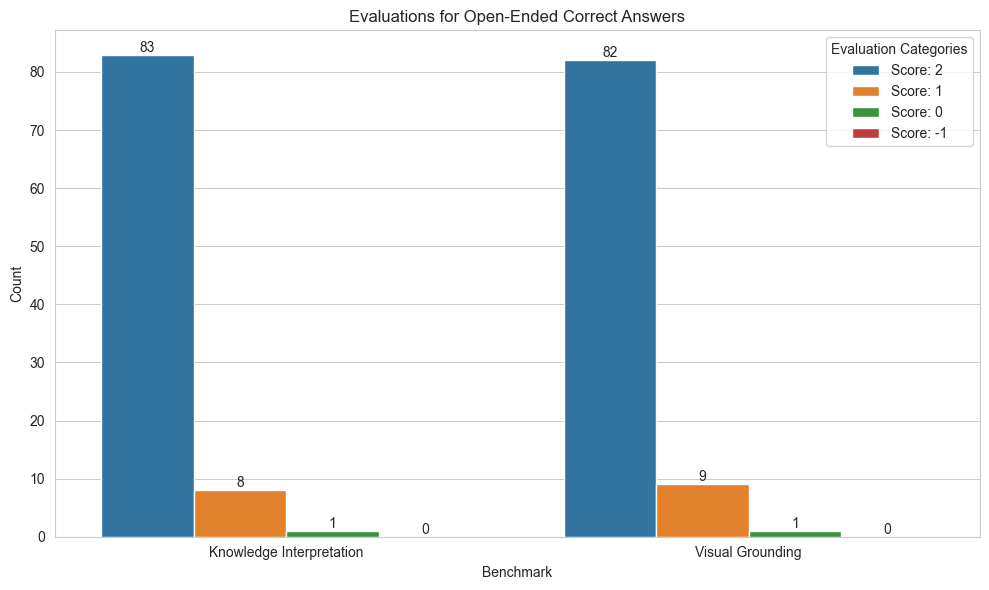

In [200]:
temp_data = correct_answer_eval_data.loc['Open-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Evaluations for Open-Ended Correct Answers')
plt.xlabel('Benchmark')
plt.ylabel('Count')
plt.legend(title='Evaluation Categories')
plt.tight_layout()
plt.show()

MCQ Correct Answers Graph

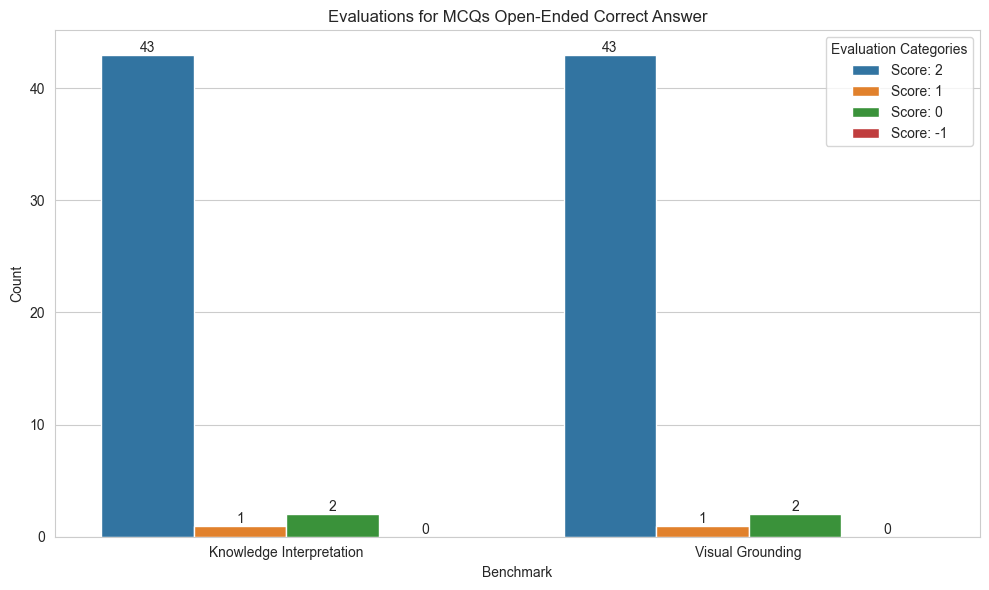

In [201]:
temp_data = correct_answer_eval_data.loc['MCQ'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Evaluations for MCQs Open-Ended Correct Answer')
plt.xlabel('Benchmark')
plt.ylabel('Count')
plt.legend(title='Evaluation Categories')
plt.tight_layout()
plt.show()

Close-Ended Correct Answers Graph

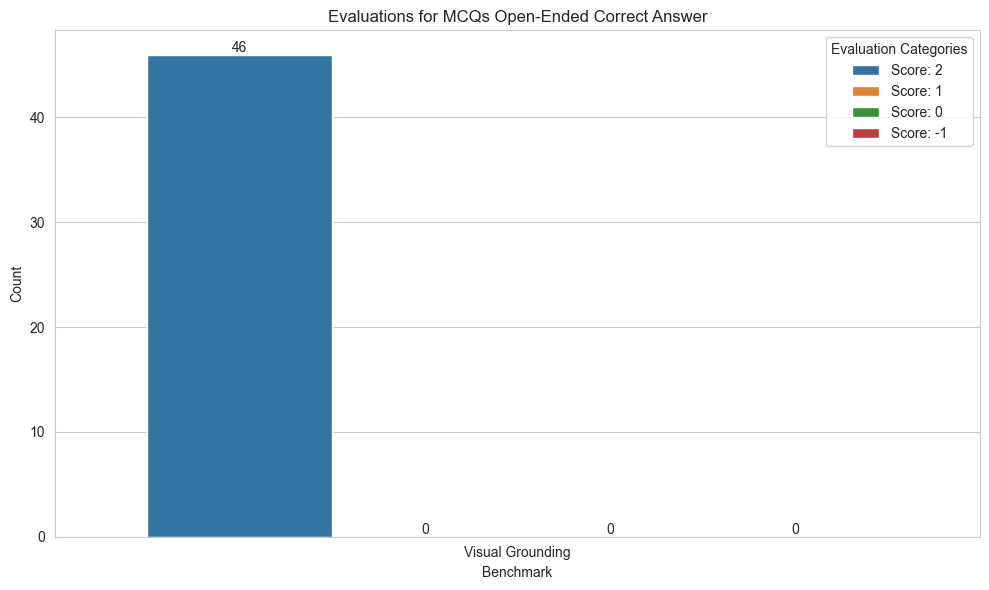

In [202]:
temp_data = correct_answer_eval_data.loc['Close-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Evaluations for MCQs Open-Ended Correct Answer')
plt.xlabel('Benchmark')
plt.ylabel('Count')
plt.legend(title='Evaluation Categories')
plt.tight_layout()
plt.show()

#### Wrong Answer

1

In [203]:
oe_wrong_answer_1_err_prox_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Wrong_Answer_1'].notnull() & eval_data['OE_Wrong_Answer_1_Err_Prox'].notnull()]
oe_wrong_answer_1_err_prox_total = len(oe_wrong_answer_1_err_prox_df)
oe_wrong_answer_1_err_prox_eval_2 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == 2])
oe_wrong_answer_1_err_prox_eval_1 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == 1])
oe_wrong_answer_1_err_prox_eval_0 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == 0])
oe_wrong_answer_1_err_prox_eval_neg_1 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == -1])

In [204]:
oe_wrong_answer_1_vis_ground_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Wrong_Answer_1'].notnull() & eval_data['OE_Wrong_Answer_1_Vis_Ground'].notnull()]
oe_wrong_answer_1_vis_ground_total = len(oe_wrong_answer_1_vis_ground_df)
oe_wrong_answer_1_vis_ground_eval_2 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == 2])
oe_wrong_answer_1_vis_ground_eval_1 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == 1])
oe_wrong_answer_1_vis_ground_eval_0 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == 0])
oe_wrong_answer_1_vis_ground_eval_neg_1 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == -1])

2

In [205]:
oe_wrong_answer_2_err_prox_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Wrong_Answer_2'].notnull() & eval_data['OE_Wrong_Answer_2_Err_Prox'].notnull()]
oe_wrong_answer_2_err_prox_total = len(oe_wrong_answer_2_err_prox_df)
oe_wrong_answer_2_err_prox_eval_2 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == 2])
oe_wrong_answer_2_err_prox_eval_1 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == 1])
oe_wrong_answer_2_err_prox_eval_0 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == 0])
oe_wrong_answer_2_err_prox_eval_neg_1 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == -1])

In [206]:
oe_wrong_answer_2_vis_ground_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Wrong_Answer_2'].notnull() & eval_data['OE_Wrong_Answer_2_Vis_Ground'].notnull()]
oe_wrong_answer_2_vis_ground_total = len(oe_wrong_answer_2_vis_ground_df)
oe_wrong_answer_2_vis_ground_eval_2 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == 2])
oe_wrong_answer_2_vis_ground_eval_1 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == 1])
oe_wrong_answer_2_vis_ground_eval_0 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == 0])
oe_wrong_answer_2_vis_ground_eval_neg_1 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == -1])

MCQ

In [207]:
mcq_wrong_answer_1_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1_Err_Prox'].notnull()]
mcq_wrong_answer_1_err_prox_total = len(mcq_wrong_answer_1_err_prox_df)
mcq_wrong_answer_1_err_prox_eval_2 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == 2])
mcq_wrong_answer_1_err_prox_eval_1 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == 1])
mcq_wrong_answer_1_err_prox_eval_0 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == 0])
mcq_wrong_answer_1_err_prox_eval_neg_1 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == -1])

In [208]:
mcq_wrong_answer_1_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1_Vis_Ground'].notnull()]
mcq_wrong_answer_1_vis_ground_total = len(mcq_wrong_answer_1_vis_ground_df)
mcq_wrong_answer_1_vis_ground_eval_2 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == 2])
mcq_wrong_answer_1_vis_ground_eval_1 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == 1])
mcq_wrong_answer_1_vis_ground_eval_0 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == 0])
mcq_wrong_answer_1_vis_ground_eval_neg_1 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == -1])

In [209]:
mcq_wrong_answer_2_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2_Err_Prox'].notnull()]
mcq_wrong_answer_2_err_prox_total = len(mcq_wrong_answer_2_err_prox_df)
mcq_wrong_answer_2_err_prox_eval_2 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == 2])
mcq_wrong_answer_2_err_prox_eval_1 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == 1])
mcq_wrong_answer_2_err_prox_eval_0 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == 0])
mcq_wrong_answer_2_err_prox_eval_neg_1 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == -1])

In [210]:
mcq_wrong_answer_2_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2_Vis_Ground'].notnull()]
mcq_wrong_answer_2_vis_ground_total = len(mcq_wrong_answer_2_vis_ground_df)
mcq_wrong_answer_2_vis_ground_eval_2 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == 2])
mcq_wrong_answer_2_vis_ground_eval_1 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == 1])
mcq_wrong_answer_2_vis_ground_eval_0 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == 0])
mcq_wrong_answer_2_vis_ground_eval_neg_1 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == -1])

In [211]:
mcq_wrong_answer_3_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3_Err_Prox'].notnull()]
mcq_wrong_answer_3_err_prox_total = len(mcq_wrong_answer_3_err_prox_df)
mcq_wrong_answer_3_err_prox_eval_2 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == 2])
mcq_wrong_answer_3_err_prox_eval_1 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == 1])
mcq_wrong_answer_3_err_prox_eval_0 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == 0])
mcq_wrong_answer_3_err_prox_eval_neg_1 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == -1])

In [212]:
mcq_wrong_answer_3_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3_Vis_Ground'].notnull()]
mcq_wrong_answer_3_vis_ground_total = len(mcq_wrong_answer_3_vis_ground_df)
mcq_wrong_answer_3_vis_ground_eval_2 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == 2])
mcq_wrong_answer_3_vis_ground_eval_1 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == 1])
mcq_wrong_answer_3_vis_ground_eval_0 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == 0])
mcq_wrong_answer_3_vis_ground_eval_neg_1 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == -1])

In [213]:
mcq_wrong_answer_4_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4_Err_Prox'].notnull()]
mcq_wrong_answer_4_err_prox_total = len(mcq_wrong_answer_4_err_prox_df)
mcq_wrong_answer_4_err_prox_eval_2 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == 2])
mcq_wrong_answer_4_err_prox_eval_1 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == 1])
mcq_wrong_answer_4_err_prox_eval_0 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == 0])
mcq_wrong_answer_4_err_prox_eval_neg_1 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == -1])

In [214]:
mcq_wrong_answer_4_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4_Vis_Ground'].notnull()]
mcq_wrong_answer_4_vis_ground_total = len(mcq_wrong_answer_4_vis_ground_df)
mcq_wrong_answer_4_vis_ground_eval_2 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == 2])
mcq_wrong_answer_4_vis_ground_eval_1 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == 1])
mcq_wrong_answer_4_vis_ground_eval_0 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == 0])
mcq_wrong_answer_4_vis_ground_eval_neg_1 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == -1])

Calculating the consolidated information all the wrong questions/answers

In [215]:
wrong_answer_que_type = [
                            'Open-Ended',
                            'Open-Ended',
                            'MCQ',
                            'MCQ'
                        ]


wrong_answer_benchmark_label = [
                                    'Error Proximity',
                                    'Visual Grounding',
                                    'Error Proximity',
                                    'Visual Grounding'
                                ]

wrong_answer_total = [  oe_wrong_answer_1_err_prox_total + oe_wrong_answer_2_err_prox_total,
                        oe_wrong_answer_1_vis_ground_total + oe_wrong_answer_2_vis_ground_total,
                        mcq_wrong_answer_1_err_prox_total + mcq_wrong_answer_2_err_prox_total + mcq_wrong_answer_3_err_prox_total + mcq_wrong_answer_4_err_prox_total,
                        mcq_wrong_answer_1_vis_ground_total + mcq_wrong_answer_2_vis_ground_total + mcq_wrong_answer_3_vis_ground_total + mcq_wrong_answer_4_vis_ground_total
                    ]

wrong_answer_eval_2 = [  oe_wrong_answer_1_err_prox_eval_2 + oe_wrong_answer_2_err_prox_eval_2,
                        oe_wrong_answer_1_vis_ground_eval_2 + oe_wrong_answer_2_vis_ground_eval_2,
                        mcq_wrong_answer_1_err_prox_eval_2 + mcq_wrong_answer_2_err_prox_eval_2 + mcq_wrong_answer_3_err_prox_eval_2 + mcq_wrong_answer_4_err_prox_eval_2,
                        mcq_wrong_answer_1_vis_ground_eval_2 + mcq_wrong_answer_2_vis_ground_eval_2 + mcq_wrong_answer_3_vis_ground_eval_2 + mcq_wrong_answer_4_vis_ground_eval_2
                    ]

wrong_answer_eval_1 = [  oe_wrong_answer_1_err_prox_eval_1 + oe_wrong_answer_2_err_prox_eval_1,
                        oe_wrong_answer_1_vis_ground_eval_1 + oe_wrong_answer_2_vis_ground_eval_1,
                        mcq_wrong_answer_1_err_prox_eval_1 + mcq_wrong_answer_2_err_prox_eval_1 + mcq_wrong_answer_3_err_prox_eval_1 + mcq_wrong_answer_4_err_prox_eval_1,
                        mcq_wrong_answer_1_vis_ground_eval_1 + mcq_wrong_answer_2_vis_ground_eval_1 + mcq_wrong_answer_3_vis_ground_eval_1 + mcq_wrong_answer_4_vis_ground_eval_1
                    ]

wrong_answer_eval_0 = [  oe_wrong_answer_1_err_prox_eval_0 + oe_wrong_answer_2_err_prox_eval_0,
                        oe_wrong_answer_1_vis_ground_eval_0 + oe_wrong_answer_2_vis_ground_eval_0,
                        mcq_wrong_answer_1_err_prox_eval_0 + mcq_wrong_answer_2_err_prox_eval_0 + mcq_wrong_answer_3_err_prox_eval_0 + mcq_wrong_answer_4_err_prox_eval_0,
                        mcq_wrong_answer_1_vis_ground_eval_0 + mcq_wrong_answer_2_vis_ground_eval_0 + mcq_wrong_answer_3_vis_ground_eval_0 + mcq_wrong_answer_4_vis_ground_eval_0
                    ]

wrong_answer_eval_neg_1 = [  oe_wrong_answer_1_err_prox_eval_neg_1 + oe_wrong_answer_2_err_prox_eval_neg_1,
                            oe_wrong_answer_1_vis_ground_eval_neg_1 + oe_wrong_answer_2_vis_ground_eval_neg_1,
                            mcq_wrong_answer_1_err_prox_eval_neg_1 + mcq_wrong_answer_2_err_prox_eval_neg_1 + mcq_wrong_answer_3_err_prox_eval_neg_1 + mcq_wrong_answer_4_err_prox_eval_neg_1,
                            mcq_wrong_answer_1_vis_ground_eval_neg_1 + mcq_wrong_answer_2_vis_ground_eval_neg_1 + mcq_wrong_answer_3_vis_ground_eval_neg_1 + mcq_wrong_answer_4_vis_ground_eval_neg_1
                        ]

wrong_answer_eval_data = pd.DataFrame({'Score: 2': wrong_answer_eval_2,
                                        'Score: 1': wrong_answer_eval_1,
                                        'Score: 0': wrong_answer_eval_0,
                                        'Score: -1': wrong_answer_eval_neg_1}, index=[wrong_answer_que_type, wrong_answer_benchmark_label])

wrong_answer_eval_data

Score: 2  Score: 1  Score: 0  Score: -1
Open-Ended Error Proximity          8        30        38          0
           Visual Grounding         6        32        38          0
MCQ        Error Proximity         19        61       101          3
           Visual Grounding        19        53       109          3

Open-Ended Wrong Answers Graph

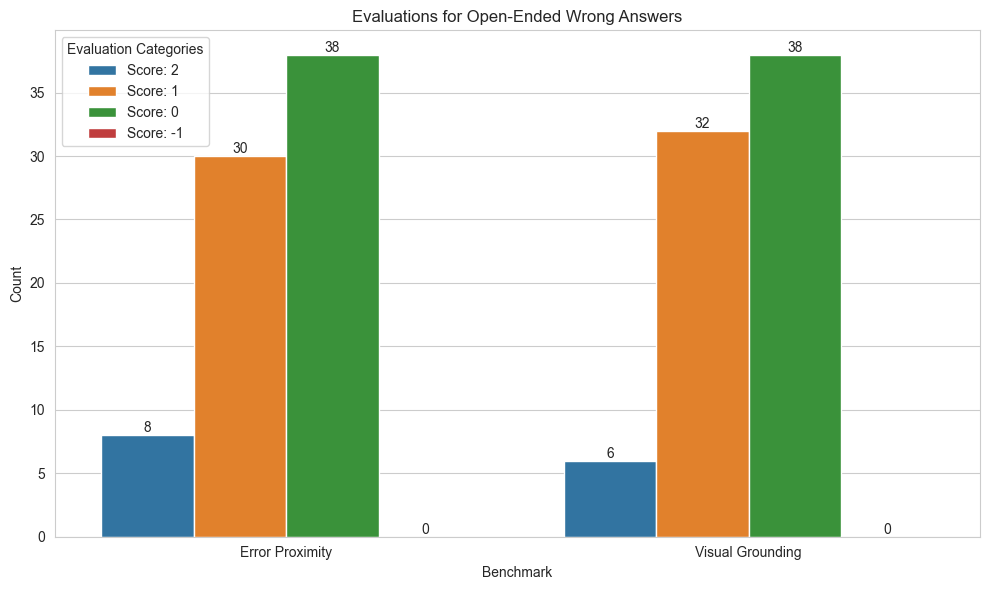

In [216]:
temp_data = wrong_answer_eval_data.loc['Open-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Evaluations for Open-Ended Wrong Answers')
plt.xlabel('Benchmark')
plt.ylabel('Count')
plt.legend(title='Evaluation Categories')
plt.tight_layout()
plt.show()

MCQ Wrong Answers Graph

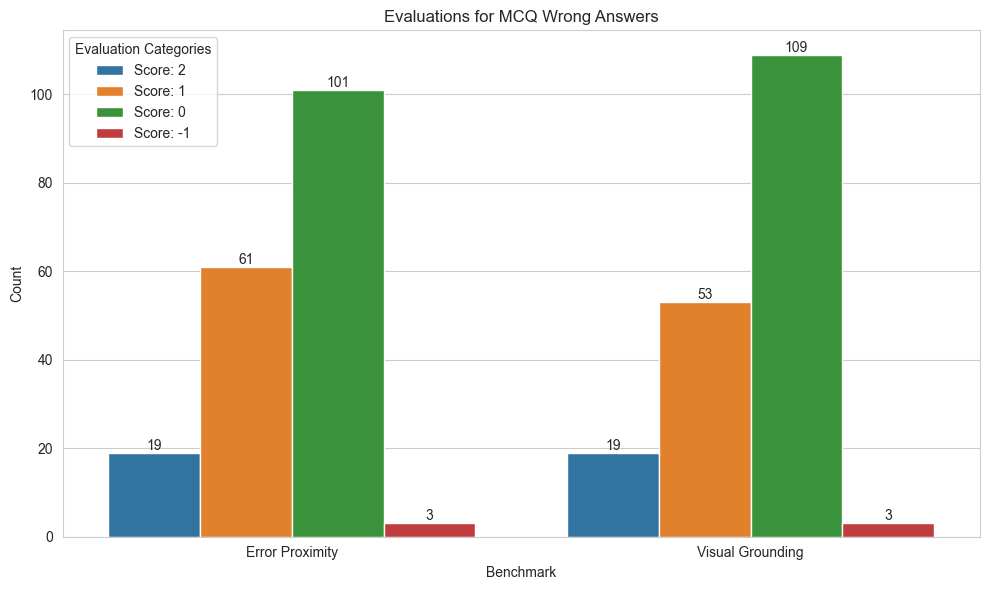

In [217]:
temp_data = wrong_answer_eval_data.loc['MCQ'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Evaluations for MCQ Wrong Answers')
plt.xlabel('Benchmark')
plt.ylabel('Count')
plt.legend(title='Evaluation Categories')
plt.tight_layout()
plt.show()